In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys , os

In [2]:
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

In [3]:
from logistic_master import LogisticRegression
from preprocessing import *
from utils import *

In [4]:
model = LogisticRegression()
test_values = np.array([-1000,0,1000])

sigmoid_outputs = model.sigmoid(test_values)
print("input values : -", test_values)
print("output values :- ",sigmoid_outputs)

print("sigmoid (0) test :- " , model.sigmoid(0))

input values : - [-1000     0  1000]
output values :-  [7.12457641e-218 5.00000000e-001 1.00000000e+000]
sigmoid (0) test :-  0.5


In [5]:
np.random.seed(42)

n_samples = 200

X = np.random.randn(n_samples, 2)

true_theta = np.array([1.5, -2.0])

linear_combination = X @ true_theta

probabilities = 1 / (1 + np.exp(-linear_combination))

y = (probabilities >= 0.5).astype(int)

bias = np.ones((n_samples, 1))
X = np.hstack((bias, X))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 3)
y shape: (200,)


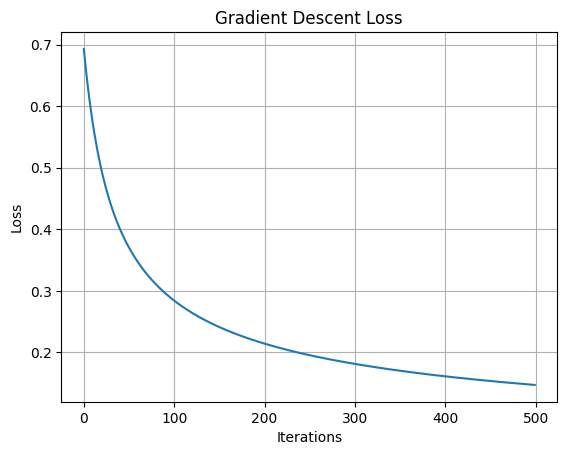

Final loss: 0.1471652076425784


In [6]:
model_gd = LogisticRegression()

model_gd.fit_gd(X, y, alpha=0.1, epochs=500)

plot_loss_curve(model_gd.loss_history, title="Gradient Descent Loss")

print("Final loss:", model_gd.loss_history[-1])

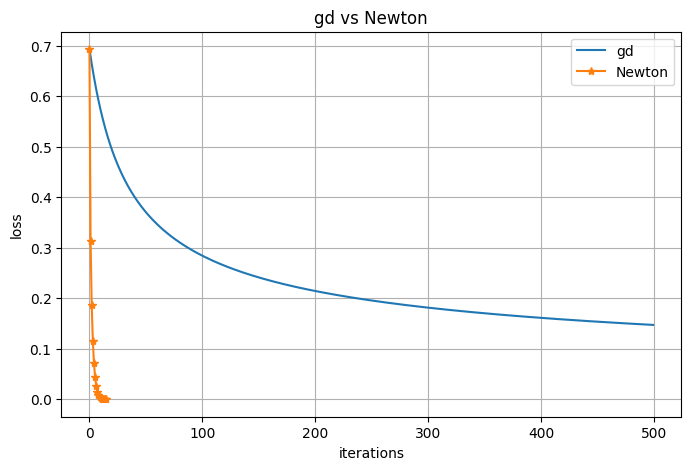

In [11]:
model_newton = LogisticRegression()

model_newton.fit_newton(X, y, max_iter=20)

plt.figure(figsize=(8,5))

plt.plot(model_gd.loss_history, label="gd")
plt.plot(model_newton.loss_history, label="Newton", marker='*')

plt.xlabel("iterations")
plt.ylabel("loss")
plt.title("gd vs Newton")

plt.legend()
plt.grid(True)
plt.show()

In [8]:
y_pred = model_gd.predict(X)

accuracy = compute_accuracy(y, y_pred)

print("accuracy:", accuracy)

accuracy: 0.995


In [9]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("theta shape:", model_gd.theta.shape)

X shape: (200, 3)
y shape: (200,)
theta shape: (3, 1)


In [10]:
H = model_gd.compute_hessian(X, model_gd.theta)

eigenvalues = np.linalg.eigvals(H)

print("hessian eigenvalues:")
print(eigenvalues)

print("all eigenvalues >= 0:", np.all(eigenvalues >= -1e-8))

hessian eigenvalues:
[0.01427145 0.08996542 0.07725986]
all eigenvalues >= 0: True
